# Exploratory Feature Analysis (EFA)
## Home Credit Default Risk

### 1. Purpose of This Notebook

This notebook focuses on the **exploratory analysis of engineered features** contained in the consolidated feature store developed for the Home Credit Default Risk problem.

While the previous notebook (02_exploratory_data_analysis) evaluated the **quality of the feature store** (e.g., missing values, duplicate records, feature cardinality, data types, and consistency checks), the purpose of this notebook is to understand the **behavior and predictive characteristics** of some engineered features.

An initial set of **ten features** was selected based on domain intuition and prior research regarding credit risk. These features were engineered from all available datasets (`bureau`, `bureau_balance`, `previous_application`, `POS_CASH_balance`, `installments_payments`, and `credit_card_balance`) and represent different aspects of a customer's financial history, including debt exposure, payment behavior, credit utilization, and delinquency patterns.

For each feature, the analysis aims to evaluate:

- Its relationship with the target (`TARGET`);
- Whether the relationship is monotonic or exhibits meaningful trends;
- The statistical reliability of the observed patterns;
- The business interpretation behind the feature and its relationship with default risk.

This notebook serves as an exploratory step to better understand the predictive information captured by the engineered features before proceeding to model development.

# 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np

from optbinning import OptimalBinning

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

import sys
from pathlib import Path

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Feature Store — Exploratory Data Analysis

In [8]:
selected_features = [
    # 1. Payment Behavior
    "INST_LATE_RATIO",
    "INST_DPD_30_RATIO",
    "POS_DPD_RATIO",
    "CC_PAYMENT_TO_BALANCE_RATIO",

    # 2. Credit Exposure
    "BUREAU_ACTIVE_LOAN_COUNT",
    "BUREAU_OVERDUE_LOAN_RATIO",
    "BUREAU_ACTIVE_DEBT_RATIO",
    "CC_UTIL_MEAN",

    # 3. Previous Applications
    "PREV_REFUSED_RATIO",
    "PREV_CREDIT_TO_APPLICATION_RATIO_MEAN",
]

splits = pd.read_parquet(
    "../data/split_assignment.parquet"
)

df = pd.read_parquet(
    "../data/feature_store_train.parquet",
    columns=["SK_ID_CURR", "TARGET"] + selected_features,
)

feature_store = df.merge(
    splits,
    on="SK_ID_CURR",
    validate="one_to_one",
).query("SPLIT == 'development'")

print(f"Rows: {feature_store.shape[0]:,}")
print(f"Columns: {feature_store.shape[1]:,}")
feature_store.head()

Rows: 246,008
Columns: 13


,SK_ID_CURR,TARGET,INST_LATE_RATIO,INST_DPD_30_RATIO,POS_DPD_RATIO,CC_PAYMENT_TO_BALANCE_RATIO,BUREAU_ACTIVE_LOAN_COUNT,BUREAU_OVERDUE_LOAN_RATIO,BUREAU_ACTIVE_DEBT_RATIO,CC_UTIL_MEAN,PREV_REFUSED_RATIO,PREV_CREDIT_TO_APPLICATION_RATIO_MEAN,SPLIT
0,100002,1,0.000000,0.0,0.0,NaN,2.0,0.375,0.509931,NaN,0.000000,1.000000,development
1,100003,0,0.000000,0.0,0.0,NaN,1.0,0.000,0.000000,NaN,0.000000,1.057664,development
2,100004,0,0.000000,0.0,0.0,NaN,0.0,0.000,0.000000,NaN,0.000000,0.828021,development
3,100006,0,0.000000,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.111111,0.675123,development
4,100007,0,0.242424,0.0,0.0,NaN,0.0,0.000,0.000000,NaN,0.000000,1.046356,development


# 1. Payment Behavior

- INST_LATE_RATIO
- INST_DPD_30_RATIO
- POS_DPD_RATIO
- CC_PAYMENT_TO_BALANCE_RATIO

---
**Feature 1.1: INST_LATE_RATIO**

Definition:
Proportion of installments paid late.

Calculated as:
Number of installments with DPD > 0 divided by total number of installments.

Interpretation:
Measures how frequently the client pays late.

Signal captured:

Behavioral consistency
Chronic delinquency tendency

In [9]:
feature_name = "INST_LATE_RATIO"
missing_rate = feature_store[feature_name].isna().mean() * 100

print(f"{feature_name} missing rate: {missing_rate:.2f}%")

INST_LATE_RATIO missing rate: 5.16%


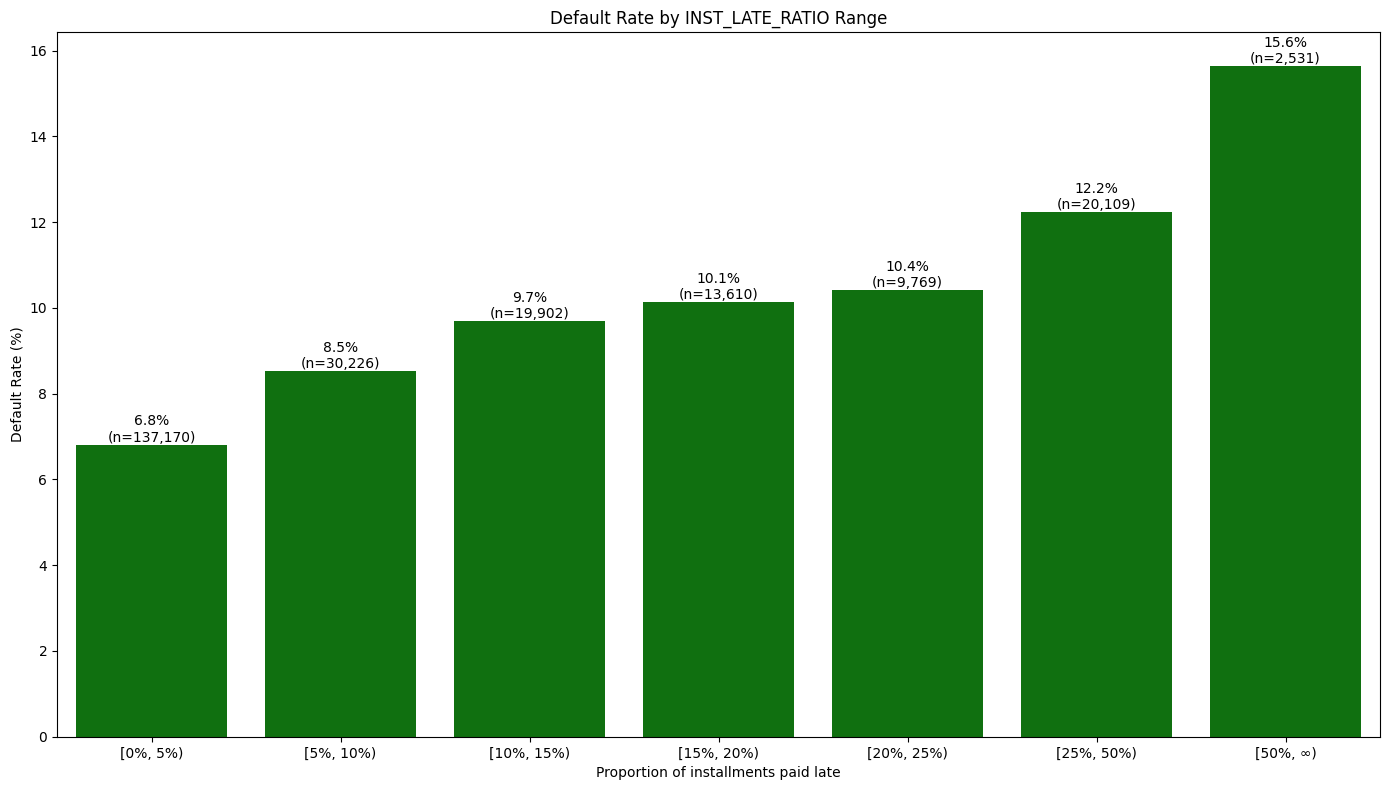

In [11]:
bins = [0, 5, 10, 15, 20, 25, 50, np.inf]

labels = [
    "[0%, 5%)",
    "[5%, 10%)",
    "[10%, 15%)",
    "[15%, 20%)",
    "[20%, 25%)",
    "[25%, 50%)",
    "[50%, ∞)"
]

df_plot = feature_store.copy()

df_plot[feature_name] = (
    round(df_plot[feature_name]*100,0)
)

df_plot["LOAN_COUNT_BIN"] = pd.cut(
    df_plot[feature_name],
    bins=bins,
    labels=labels,
    right=False
)

default_rate = (
    df_plot
    .groupby("LOAN_COUNT_BIN", observed=False)
    .agg(
        default_rate=("TARGET", "mean"),
        total_clients=("TARGET", "count"),
        total_defaults=("TARGET", "sum")
    )
    .reset_index()
)

default_rate["default_rate"] *= 100

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=default_rate,
    x="LOAN_COUNT_BIN",
    y="default_rate",
    color="green"
)

plt.title(f"Default Rate by {feature_name} Range")
plt.xlabel("Proportion of installments paid late")
plt.ylabel("Default Rate (%)")

for p, row in zip(ax.patches, default_rate.itertuples()):
    height = p.get_height()

    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.1f}%\n(n={row.total_clients:,})",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

---
**Feature 1.2: INST_DPD_30_RATIO**

Definition:
Proportion of installments with DPD greater than 30 days.

Interpretation:
Measures frequency of severe DPD.

Signal captured:

- Material credit deterioration
- Risk of transition into default

In [12]:
feature_name = "INST_DPD_30_RATIO"
missing_rate = feature_store[feature_name].isna().mean() * 100

print(f"{feature_name} missing rate: {missing_rate:.2f}%")

INST_DPD_30_RATIO missing rate: 5.16%


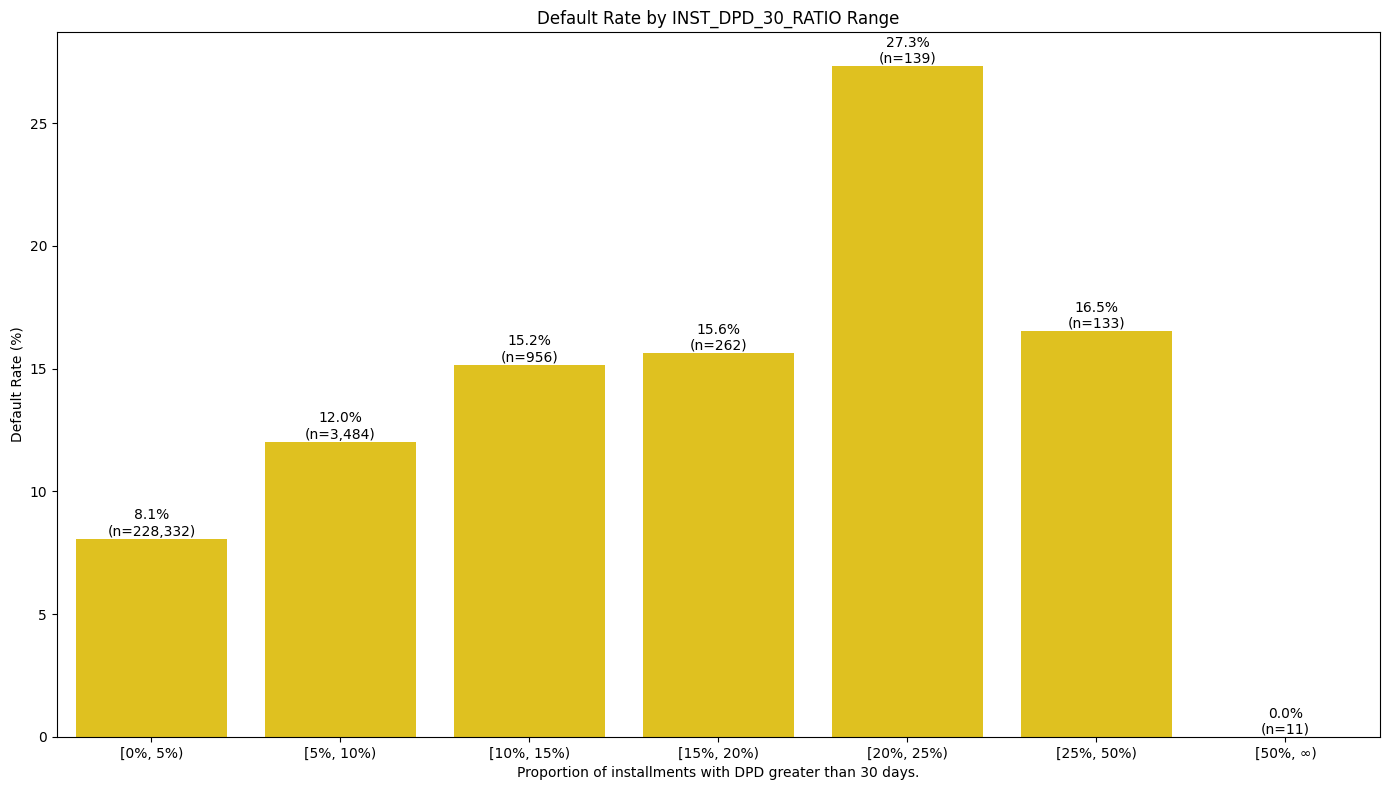

In [13]:
df_plot = feature_store[["TARGET", feature_name]].copy()

df_plot[feature_name] = (
    round(df_plot[feature_name]*100,0)
)

df_plot["LOAN_COUNT_BIN"] = pd.cut(
    df_plot[feature_name],
    bins=bins,
    labels=labels,
    right=False
)

bins = [-0.1, 0.1, 5, 10, 20, np.inf]

labels = [
    "0%",
    "(0%, 5%)",
    "[5%, 10%)",
    "[10%, 20%)",
    "≥20%"
]

default_rate = (
    df_plot
    .groupby("LOAN_COUNT_BIN", observed=False)
    .agg(
        default_rate=("TARGET", "mean"),
        total_clients=("TARGET", "count"),
        total_defaults=("TARGET", "sum")
    )
    .reset_index()
)

default_rate["default_rate"] *= 100

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=default_rate,
    x="LOAN_COUNT_BIN",
    y="default_rate",
    color="gold"
)

plt.title(f"Default Rate by {feature_name} Range")
plt.xlabel("Proportion of installments with DPD greater than 30 days.")
plt.ylabel("Default Rate (%)")

for p, row in zip(ax.patches, default_rate.itertuples()):
    height = p.get_height()

    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.1f}%\n(n={row.total_clients:,})",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [14]:
df_plot[feature_name].quantile(
    [.50,.75,.90,.95,.99,.995,.999]
)

0.500     0.0
0.750     0.0
0.900     0.0
0.950     2.0
0.990     8.0
0.995    11.0
0.999    20.0
Name: INST_DPD_30_RATIO, dtype: float32

In [15]:
print(f"{round((df_plot[feature_name] == 0).mean()*100,2)}% of customers never experienced a 30+ day overdue installment")

88.71% of customers never experienced a 30+ day overdue installment


**INST_DPD_30_RATIO** demonstrates a strong positive relationship with default risk. Customers with a higher proportion of installments paid more than 30 days late exhibit progressively higher default rates, indicating that repeated severe payment delays are closely associated with future default. Notably, **88.7%** of customers never experienced a 30+ day overdue installment (`INST_DPD_30_RATIO`= 0%), highlighting that severe payment delays are relatively rare in the portfolio. As the proportion of severely overdue installments increases, default rates rise consistently, reinforcing the feature's ability to capture persistent late payment behavior. The highest ratio groups should be interpreted with some caution due to the smaller number of observations, but the overall trend remains clear.

---
**Feature 1.3: POS_DPD_RATIO**

**Definition:**
Proportion of months with DPD greater than zero.

Formula: POS_DPD_RATIO = Months_with_DPD / POS_RECORD_COUNT

Interpretation:
Measures how frequently payment delays occurred.

**Risk intuition:**

- Close to 1 → persistent late payments

- Close to 0 → generally on-time payments

In [16]:
feature_name = "POS_DPD_RATIO"
missing_rate = feature_store[feature_name].isna().mean() * 100

print(f"{feature_name} missing rate: {missing_rate:.2f}%")

POS_DPD_RATIO missing rate: 5.87%


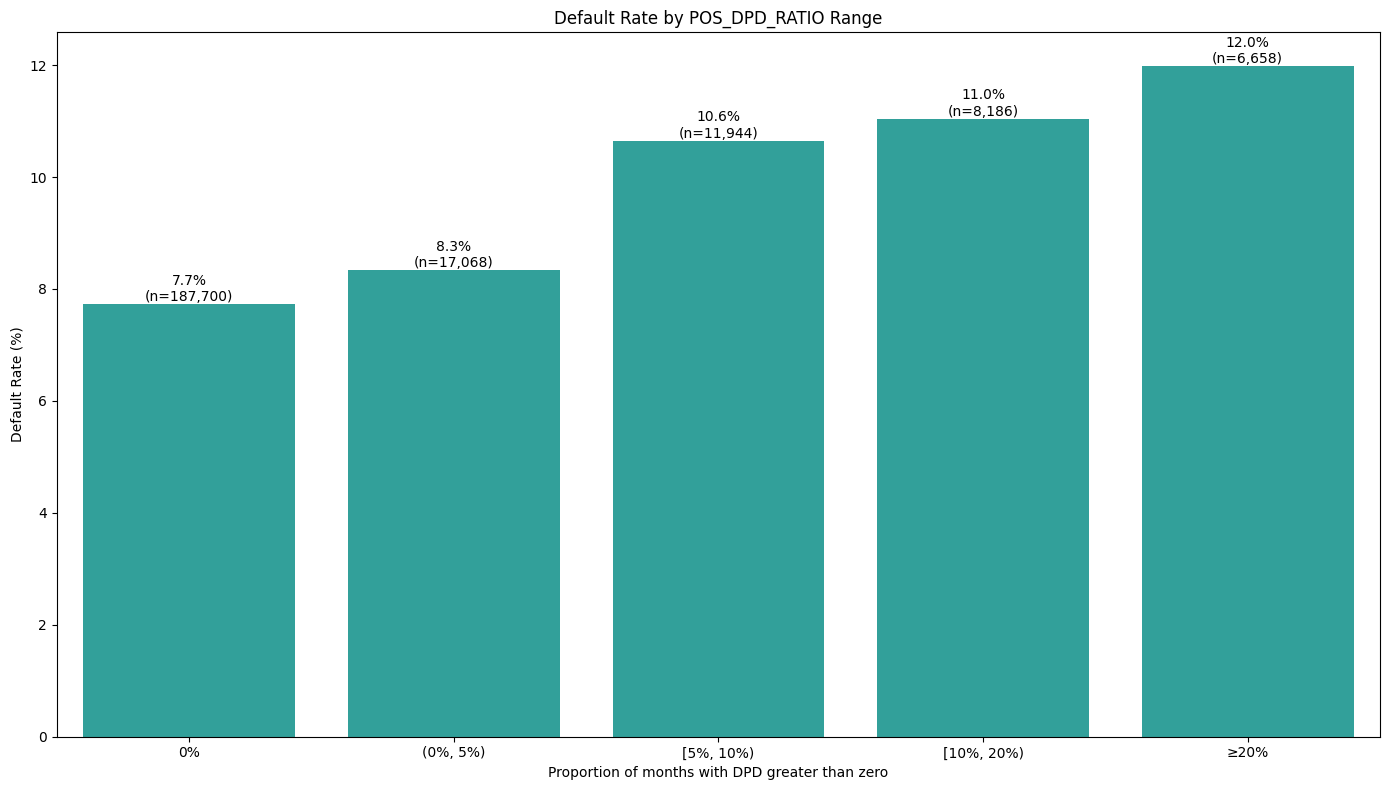

In [17]:
df_plot = feature_store[["TARGET", feature_name]].copy()

df_plot[feature_name] = (
    round(df_plot[feature_name]*100,0)
)

df_plot["LOAN_COUNT_BIN"] = pd.cut(
    df_plot[feature_name],
    bins=bins,
    labels=labels,
    right=False
)

bins = [-0.1, 0.1, 5, 10, 25, np.inf]

labels = [
    "0%",
    "(0%, 5%)",
    "[5%, 10%)",
    "[10%, 25%)",
    "≥25%"
]

default_rate = (
    df_plot
    .groupby("LOAN_COUNT_BIN", observed=False)
    .agg(
        default_rate=("TARGET", "mean"),
        total_clients=("TARGET", "count"),
        total_defaults=("TARGET", "sum")
    )
    .reset_index()
)

default_rate["default_rate"] *= 100

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=default_rate,
    x="LOAN_COUNT_BIN",
    y="default_rate",
    color="lightseagreen"
)

plt.title(f"Default Rate by {feature_name} Range")
plt.xlabel("Proportion of months with DPD greater than zero")
plt.ylabel("Default Rate (%)")

for p, row in zip(ax.patches, default_rate.itertuples()):
    height = p.get_height()

    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.1f}%\n(n={row.total_clients:,})",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [18]:
df_plot[feature_name].quantile(
    [0, .25, .50,.75,.90,.95,.99,.995,.999]
)

0.000     0.0
0.250     0.0
0.500     0.0
0.750     0.0
0.900     6.0
0.950    12.0
0.990    42.0
0.995    61.0
0.999    89.0
Name: POS_DPD_RATIO, dtype: float32

In [19]:
print(f"{round((df_plot[feature_name] == 0).mean()*100,2)}% of customers never experienced payment delays (DPD > 0) on POS_CASH contracts during the entire observed history.")

76.3% of customers never experienced payment delays (DPD > 0) on POS_CASH contracts during the entire observed history.


---
**Feature 1.4: CC_PAYMENT_TO_BALANCE_RATIO**

**Definition:**  
Ratio between the total amount paid and the total outstanding balance observed across the customer's credit card history.

Calculated as:  
SUM(AMT_PAYMENT_TOTAL_CURRENT) / SUM(AMT_BALANCE)

**Interpretation:**  
Indicates how much of the customer's observed outstanding balance is covered by payments over the available credit card history.

Using the ratio of aggregated amounts instead of the average of monthly payment-to-balance ratios reduces sensitivity to months where AMT_BALANCE is close to zero, which can otherwise generate extreme ratio values.

**Signal captured:**
- Payment discipline  
- Ability to reduce debt  
- Capacity to cover outstanding balances  

In [20]:
feature_name = "CC_PAYMENT_TO_BALANCE_RATIO"
missing_rate = feature_store[feature_name].isna().mean() * 100

print(f"{feature_name} missing rate: {missing_rate:.2f}%")

CC_PAYMENT_TO_BALANCE_RATIO missing rate: 71.67%


In [21]:
def analyze_missing_history(df, feature_name, target="TARGET"):
    history_col = f"HAS_{feature_name}_HISTORY"

    # Missing rate
    missing_rate = df[feature_name].isna().mean() * 100

    # Availability flag
    df[history_col] = (
        df[feature_name]
        .notna()
        .astype("int8")
    )

    # Default rate by availability
    summary = (
        df
        .groupby(history_col)
        .agg(
            total_clients=(target, "count"),
            total_defaults=(target, "sum"),
            default_rate=(target, "mean")
        )
        .reset_index()
        .rename(columns={history_col: "has_history"})
    )

    summary["default_rate"] *= 100
    summary["feature_name"] = feature_name
    summary["missing_rate"] = missing_rate

    return summary

In [22]:
features = [
    "CC_PAYMENT_TO_BALANCE_RATIO",
    "CC_UTIL_MEAN"
]

cc_missing_analysis = pd.concat(
    [
        analyze_missing_history(feature_store, feature)
        for feature in features
    ],
    ignore_index=True
)

cc_missing_analysis[
    [
        "feature_name",
        "missing_rate",
        "has_history",
        "total_clients",
        "total_defaults",
        "default_rate"
    ]
]

,feature_name,missing_rate,has_history,total_clients,total_defaults,default_rate
0,CC_PAYMENT_TO_BALANCE_RATIO,71.674498,0,176325,13816,7.835531
1,CC_PAYMENT_TO_BALANCE_RATIO,71.674498,1,69683,6044,8.673565
2,CC_UTIL_MEAN,71.674498,0,176325,13816,7.835531
3,CC_UTIL_MEAN,71.674498,1,69683,6044,8.673565


### Credit Card Features — Missing Data Analysis

Features derived from the `credit_card_balance` dataset have limited coverage in the feature store. For `CC_PAYMENT_TO_BALANCE_RATIO` and `CC_UTIL_MEAN` (Section 2. Credit Exposure), approximately **71.7% of observations are missing**, meaning that the features are available for only **28.3% of clients**.

The default rate was compared between clients with and without available `CC_PAYMENT_TO_BALANCE_RATIO` information. Clients with available information presented a default rate of **8.67%**, compared with **7.84%** among clients with missing values. A similar analysis performed for `CC_UTIL_MEAN` produced the same default rates for the missing and observed groups.

The consistency of these results across different credit card features suggests that missingness is likely driven by the availability of records in the underlying `credit_card_balance` dataset rather than by the individual feature calculations. Therefore, missing values should be interpreted as a dataset coverage characteristic and analyzed separately from the behavioral information captured by each credit card feature.

In [23]:
feature_name = "CC_PAYMENT_TO_BALANCE_RATIO"

df_cc = feature_store.loc[
    feature_store[feature_name].notna(),
    [feature_name, "TARGET"]
].copy()

optb = OptimalBinning(
    name=feature_name,
    dtype="numerical",
    solver="cp"
)

optb.fit(
    df_cc[feature_name],
    df_cc["TARGET"]
)

optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.00)",22236,0.319102,20997,1239,0.055720,0.475915,0.059462,0.007363
1,"[0.00, 0.05)",5154,0.073964,4240,914,0.177338,-0.819672,0.069343,0.008433
2,"[0.05, 0.06)",3595,0.051591,3062,533,0.148261,-0.605858,0.024278,0.002989
3,"[0.06, 0.08)",4310,0.061852,3873,437,0.101392,-0.172309,0.001972,0.000246
4,"[0.08, 0.54)",27814,0.399150,25327,2487,0.089415,-0.033367,0.000451,0.000056
5,"[0.54, inf)",6574,0.094342,6140,434,0.066018,0.295375,0.007288,0.000908
6,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
7,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,69683,1.000000,63639,6044,0.086736,,0.162794,0.019996


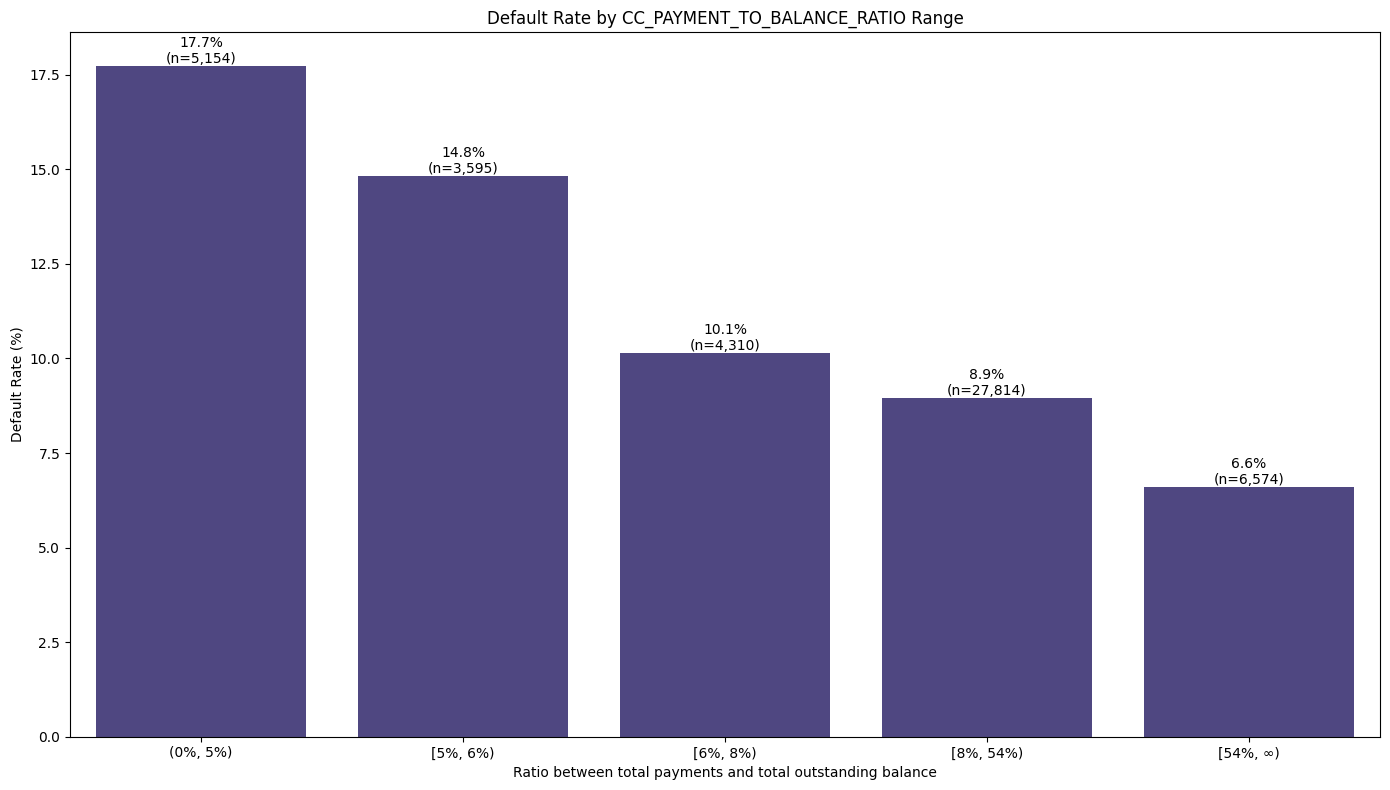

In [24]:
# Optimal bins for CC_PAYMENT_TO_BALANCE_RATIO
bins = np.concatenate([
    optb.splits,
    [np.inf]
])

labels = [
    "(0%, 5%)",
    "[5%, 6%)",
    "[6%, 8%)",
    "[8%, 54%)",
    "[54%, ∞)"
]

df_plot = feature_store[
    ["TARGET", feature_name]
].copy()


df_plot = df_plot[
    df_plot[feature_name] > 0
].copy()


df_plot["PAYMENT_RATIO_BIN"] = pd.cut(
    df_plot[feature_name],
    bins=bins,
    labels=labels,
    right=False
)

default_rate = (
    df_plot
    .groupby("PAYMENT_RATIO_BIN", observed=False)
    .agg(
        default_rate=("TARGET", "mean"),
        total_clients=("TARGET", "count"),
        total_defaults=("TARGET", "sum")
    )
    .reset_index()
)

default_rate["default_rate"] *= 100

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=default_rate,
    x="PAYMENT_RATIO_BIN",
    y="default_rate",
    color="darkslateblue"
)

plt.title(
    "Default Rate by CC_PAYMENT_TO_BALANCE_RATIO Range"
)

plt.xlabel(
    "Ratio between total payments and total outstanding balance"
)

plt.ylabel("Default Rate (%)")

# Labels
for p, row in zip(ax.patches, default_rate.itertuples()):
    height = p.get_height()

    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.1f}%\n(n={row.total_clients:,})",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

---
`CC_PAYMENT_TO_BALANCE_RATIO` shows a clear inverse relationship with default risk among clients with positive ratios. The default rate decreases consistently from **17.7%** for ratios below 5% to **6.6%** for ratios above 54%.

The analysis was performed **only on clients with available credit card information**, excluding missing values. The main hypothesis is that these missing values reflect **absence of credit card history** rather than a systematic data-quality or feature-construction issue. The bin thresholds were identified using **Optimal Binning**, and zero ratios were analyzed separately due to their distinct behavior.

# 2. Credit Exposure

- BUREAU_ACTIVE_LOAN_COUNT
- BUREAU_ACTIVE_DEBT_RATIO
- CC_UTIL_MEAN

---
**Feature 2.1: BUREAU_ACTIVE_LOAN_COUNT**

Definition:
Proportion of active loans relative to total loans.

Formula:
ACTIVE_LOAN_RATIO = Active Loans / (Active Loans + Closed Loans)

Interpretation:
Represents how much of the customer’s external credit history is still generating financial obligations.

Risk intuition:

Close to 1 → highly leveraged

Close to 0 → mostly closed obligations

In [25]:
feature_name = "BUREAU_ACTIVE_LOAN_COUNT"
missing_rate = feature_store[feature_name].isna().mean() * 100

print(f"{feature_name} missing rate: {missing_rate:.2f}%")

BUREAU_ACTIVE_LOAN_COUNT missing rate: 14.33%


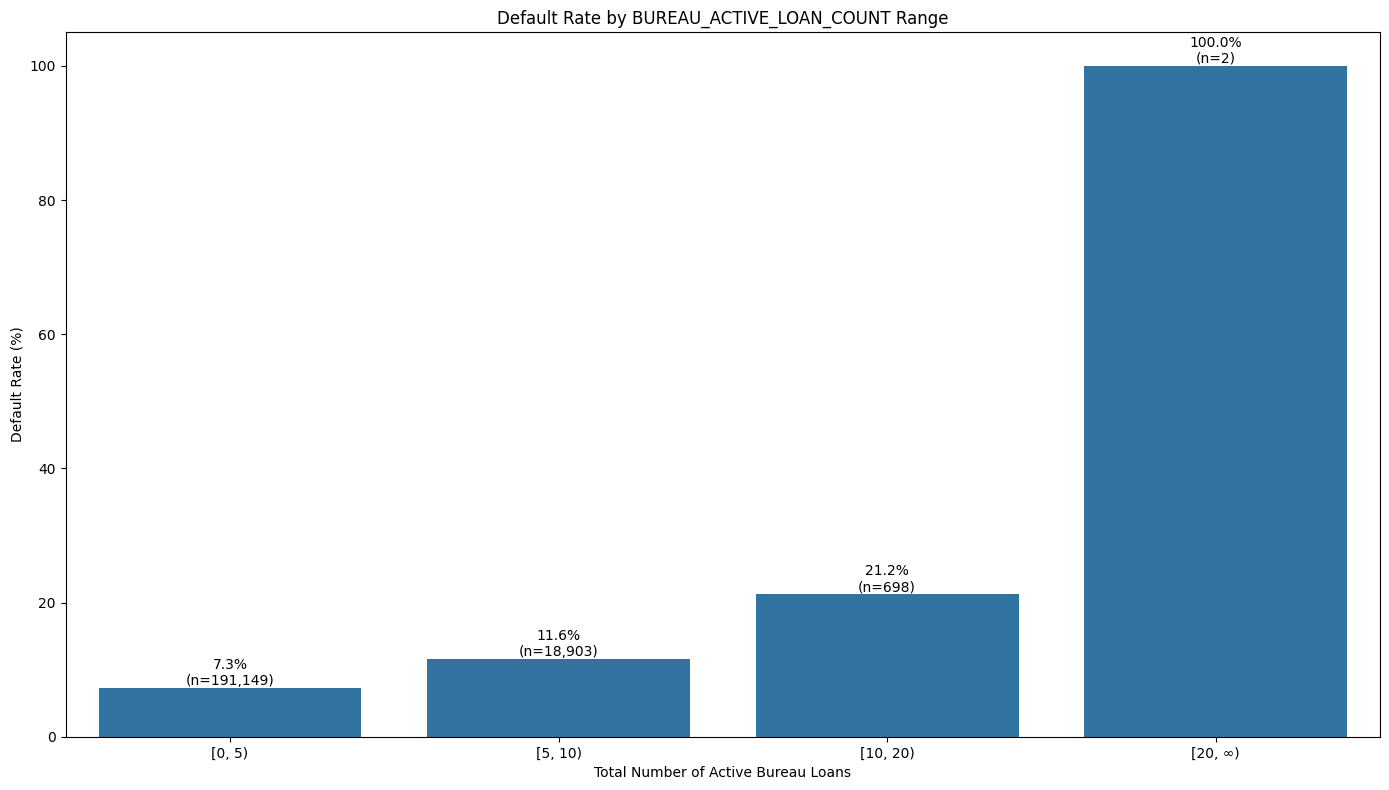

In [26]:
bins = [0, 5, 10, 20, np.inf]

labels = [
    "[0, 5)",
    "[5, 10)",
    "[10, 20)",
    "[20, ∞)"
]

df_plot = feature_store[["TARGET", feature_name]].copy()

df_plot["LOAN_COUNT_BIN"] = pd.cut(
    df_plot[feature_name],
    bins=bins,
    labels=labels,
    right=False
)

default_rate = (
    df_plot
    .groupby("LOAN_COUNT_BIN", observed=False)
    .agg(
        default_rate=("TARGET", "mean"),
        total_clients=("TARGET", "count"),
        total_defaults=("TARGET", "sum")
    )
    .reset_index()
)

default_rate["default_rate"] *= 100

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=default_rate,
    x="LOAN_COUNT_BIN",
    y="default_rate"
)

plt.title(f"Default Rate by {feature_name} Range")
plt.xlabel("Total Number of Active Bureau Loans")
plt.ylabel("Default Rate (%)")

for p, row in zip(ax.patches, default_rate.itertuples()):
    height = p.get_height()

    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.1f}%\n(n={row.total_clients:,})",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

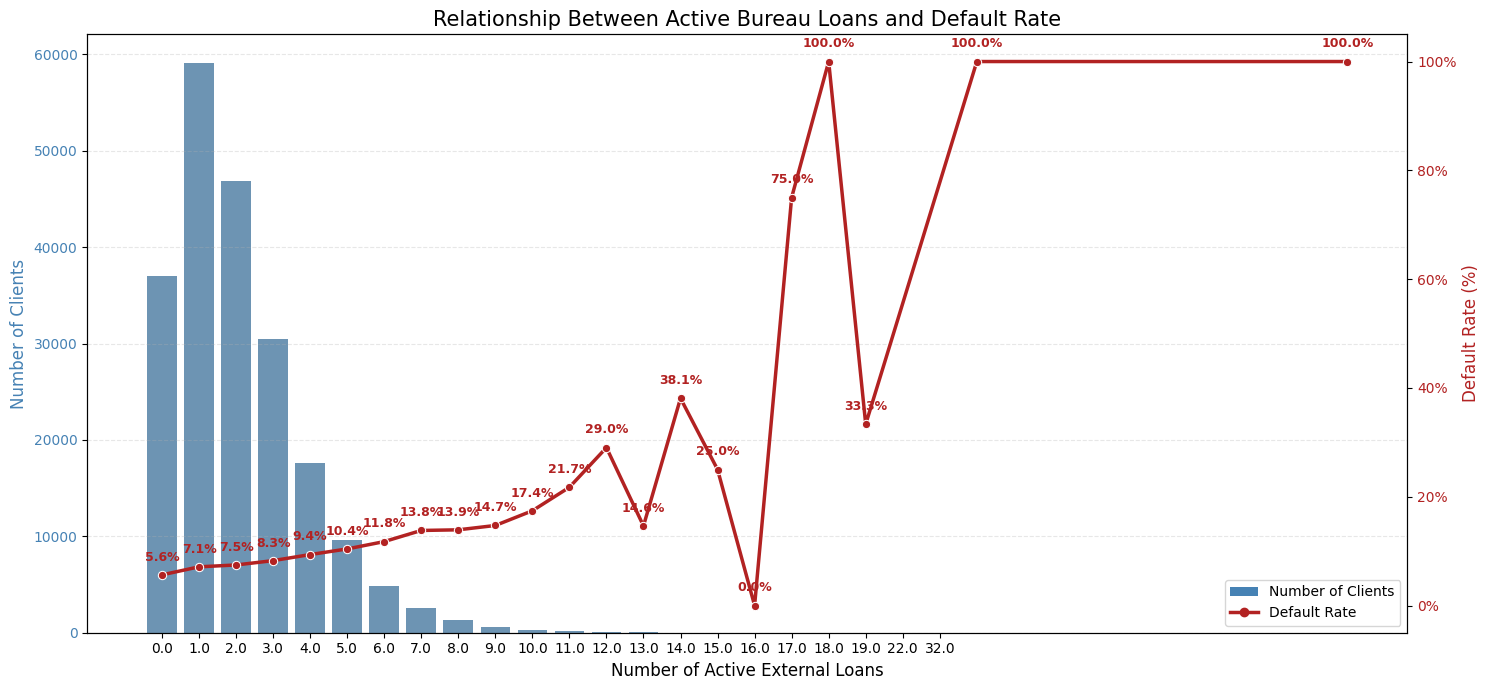

In [27]:
summary = (
    df_plot
    .groupby(feature_name)
    .agg(
        default_rate=("TARGET", "mean"),
        clients=("TARGET", "count")
    )
    .reset_index()
)

summary["default_rate"] *= 100

fig, ax1 = plt.subplots(figsize=(15, 7))

# Bar plot: Number of clients
bars = sns.barplot(
    data=summary,
    x=feature_name,
    y="clients",
    color="steelblue",
    alpha=0.85,
    ax=ax1
)

ax1.set_xlabel("Number of Active External Loans", fontsize=12)
ax1.set_ylabel("Number of Clients", fontsize=12, color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Line plot: Default rate
ax2 = ax1.twinx()

line = sns.lineplot(
    data=summary,
    x=feature_name,
    y="default_rate",
    marker="o",
    linewidth=2.5,
    color="firebrick",
    ax=ax2
)


for x, y in zip(summary[feature_name], summary["default_rate"]):
    ax2.annotate(
        f"{y:.1f}%",
        xy=(x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        color="firebrick",
        fontweight="bold"
    )


ax2.set_ylabel("Default Rate (%)", fontsize=12, color="firebrick")
ax2.tick_params(axis="y", labelcolor="firebrick")
ax2.yaxis.set_major_formatter(PercentFormatter())

plt.title(
    "Relationship Between Active Bureau Loans and Default Rate",
    fontsize=15,
)

plt.xticks(rotation=45)

ax1.grid(axis="y", linestyle="--", alpha=0.3)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor="steelblue", label="Number of Clients"),
    Line2D([0], [0], color="firebrick", marker="o",
           linewidth=2.5, label="Default Rate")
]

ax1.legend(
    handles=legend_elements,
    loc="lower right"
)

plt.tight_layout()
plt.show()

**BUREAU_ACTIVE_LOAN_COUNT** appears to be a strong predictor of default. The default rate increases consistently from 7.3% to 21.2% as the number of active external loans rises from 0-4 to 10-19, suggesting a positive relationship between current external debt exposure and credit risk. The final bin (20+) also exhibits a high observed default rate (100%), although its interpretation is limited by the extremely small sample size (n=2).

Although default rates become substantially higher beyond 12 active loans, these observations should be interpreted with caution due to the extremely small sample size. In fact, 85,6% of customers have 12 or fewer active loans, making the higher observed default rates increasingly volatile and less representative of the overall population.

---
**Feature 2.2: BUREAU_ACTIVE_DEBT_RATIO**

Definition:
Ratio of outstanding debt to total granted credit for active accounts.

Formula:
ACTIVE_DEBT_RATIO = Debt Sum / Credit Sum

Interpretation:

Close to 1 → credit almost fully utilized

Close to 0 → low utilization

In [31]:
feature_name = "BUREAU_ACTIVE_DEBT_RATIO"
missing_rate = feature_store[feature_name].isna().mean() * 100

print(f"{feature_name} missing rate: {missing_rate:.2f}%")

BUREAU_ACTIVE_DEBT_RATIO missing rate: 14.33%


In [32]:
x = feature_store[feature_name]
y = feature_store["TARGET"]

optb = OptimalBinning(
    name=feature_name,
    dtype="numerical",
    solver="cp"
)

optb.fit(x, y)
binning_table = optb.binning_table.build()
binning_table

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.00)",63991,0.260118,60359,3632,0.056758,0.378045,0.031763,0.003947
1,"[0.00, 0.31)",27321,0.111057,25524,1797,0.065774,0.221019,0.004947,0.000617
2,"[0.31, 0.54)",27901,0.113415,25992,1909,0.068420,0.178727,0.003362,0.000420
3,"[0.54, 0.66)",18397,0.074782,17041,1356,0.073708,0.098601,0.000698,0.000087
4,"[0.66, 0.76)",18221,0.074067,16726,1495,0.082048,-0.017644,0.000023,0.000003
5,"[0.76, 0.85)",17549,0.071335,15882,1667,0.094991,-0.178321,0.002445,0.000305
6,"[0.85, 0.94)",19801,0.080489,17573,2228,0.112520,-0.367223,0.012662,0.001574
7,"[0.94, inf)",17571,0.071425,15363,2208,0.125662,-0.492607,0.021303,0.002636
8,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
9,Missing,35256,0.143312,31688,3568,0.101203,-0.248549,0.009827,0.001225


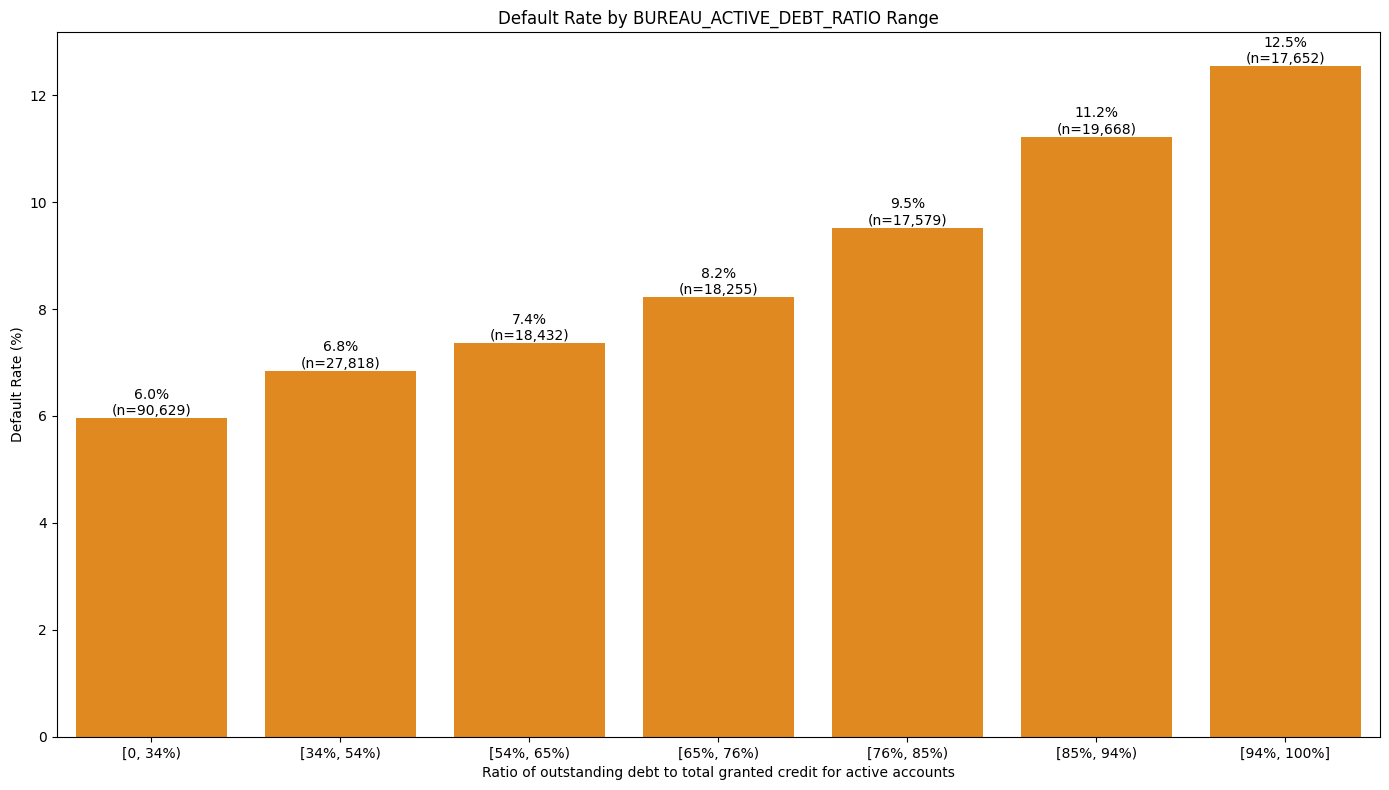

In [33]:
bins = list(np.round(optb.splits,3))
bins.append(np.float64(100))

labels = [
    "[0, 34%)",
    "[34%, 54%)",
    "[54%, 65%)",
    "[65%, 76%)",
    "[76%, 85%)",
    "[85%, 94%)",
    "[94%, 100%]"
]

df_plot = feature_store[["TARGET", feature_name]].copy()


df_plot["LOAN_COUNT_BIN"] = pd.cut(
    df_plot[feature_name],
    bins=bins,
    labels=labels,
    right=False
)

default_rate = (
    df_plot
    .groupby("LOAN_COUNT_BIN", observed=False)
    .agg(
        default_rate=("TARGET", "mean"),
        total_clients=("TARGET", "count"),
        total_defaults=("TARGET", "sum")
    )
    .reset_index()
)

default_rate["default_rate"] *= 100

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=default_rate,
    x="LOAN_COUNT_BIN",
    y="default_rate",
    color="darkorange"
)

plt.title(f"Default Rate by {feature_name} Range")
plt.xlabel("Ratio of outstanding debt to total granted credit for active accounts")
plt.ylabel("Default Rate (%)")

for p, row in zip(ax.patches, default_rate.itertuples()):
    height = p.get_height()

    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.1f}%\n(n={row.total_clients:,})",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

**BUREAU_ACTIVE_DEBT_RATIO** shows a strong and highly monotonic relationship with default risk. The default rate increases steadily from 6.0% for clients with less than 34% of their active credit amount represented by outstanding debt to 12.5% for clients with ratios above 94%, more than doubling across the observed range.

---
**Feature 2.3: CC_UTIL_MEAN**

Definition:
Average credit utilization ratio across all months.

Calculated as:
AMT_BALANCE divided by AMT_CREDIT_LIMIT_ACTUAL

Interpretation:
Represents how much of the available credit limit the client typically uses.

Signal captured:

1. Credit dependency

2. Financial pressure

In [34]:
feature_name = "CC_UTIL_MEAN"
missing_rate = feature_store[feature_name].isna().mean() * 100

print(f"{feature_name} missing rate: {missing_rate:.2f}%")

CC_UTIL_MEAN missing rate: 71.67%


In [35]:
feature_name = "CC_UTIL_MEAN"

df_cc = feature_store.loc[
    feature_store[feature_name].notna(),
    [feature_name, "TARGET"]
].copy()

optb = OptimalBinning(
    name=feature_name,
    dtype="numerical",
    solver="cp"
)

optb.fit(
    df_cc[feature_name],
    df_cc["TARGET"]
)

optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.12)",28429,0.407976,26862,1567,0.055120,0.487389,0.079364,9.823419e-03
1,"[0.12, 0.25)",6303,0.090452,5862,441,0.069967,0.233041,0.004462,5.565361e-04
2,"[0.25, 0.37)",6867,0.098546,6361,506,0.073686,0.177244,0.002878,3.592248e-04
3,"[0.37, 0.45)",3913,0.056154,3577,336,0.085868,0.011008,0.000007,8.467255e-07
4,"[0.45, 0.56)",5590,0.080220,5046,544,0.097317,-0.126759,0.001358,1.696735e-04
5,"[0.56, 0.70)",6220,0.089261,5514,706,0.113505,-0.29873,0.009011,1.122232e-03
6,"[0.70, 0.79)",3664,0.052581,3211,453,0.123635,-0.395715,0.009693,1.203731e-03
7,"[0.79, 0.89)",3998,0.057374,3408,590,0.147574,-0.600402,0.026457,3.258325e-03
8,"[0.89, inf)",4699,0.067434,3798,901,0.191743,-0.915436,0.081834,9.886349e-03
9,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000e+00


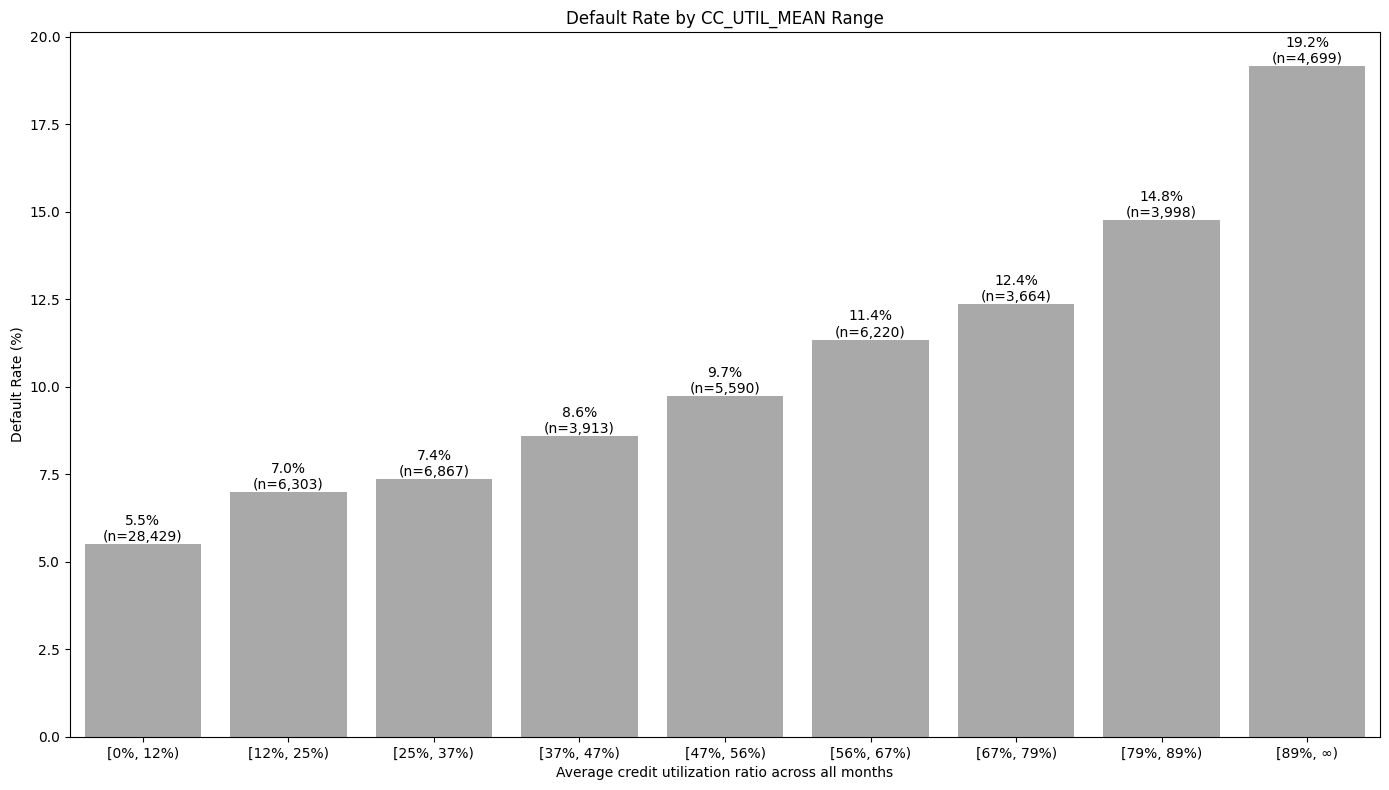

In [36]:
# Optimal bins for CC_UTIL_MEAN
bins = np.concatenate([
    [0],
    optb.splits,
    [np.inf]
])

labels = [
    "[0%, 12%)",
    "[12%, 25%)",
    "[25%, 37%)",
    "[37%, 47%)",
    "[47%, 56%)",
    "[56%, 67%)",
    "[67%, 79%)",
    "[79%, 89%)",
    "[89%, ∞)"
]

df_plot = feature_store[
    ["TARGET", feature_name]
].copy()

df_plot["CC_UTIL_BIN"] = pd.cut(
    df_plot[feature_name],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

default_rate = (
    df_plot
    .groupby("CC_UTIL_BIN", observed=False)
    .agg(
        default_rate=("TARGET", "mean"),
        total_clients=("TARGET", "count"),
        total_defaults=("TARGET", "sum")
    )
    .reset_index()
)

default_rate["default_rate"] *= 100

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=default_rate,
    x="CC_UTIL_BIN",
    y="default_rate",
    color="darkgrey"
)

plt.title(f"Default Rate by {feature_name} Range")

plt.xlabel(
    "Average credit utilization ratio across all months"
)

plt.ylabel("Default Rate (%)")

for p, row in zip(ax.patches, default_rate.itertuples()):
    height = p.get_height()

    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.1f}%\n(n={row.total_clients:,})",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

---
`CC_UTIL_MEAN` shows a clear and monotonic positive relationship with default risk. The default rate increases consistently from **5.5%** for clients with average credit utilization below 12% to **19.2%** for utilization above 89%, indicating that higher reliance on the available credit limit is associated with greater credit risk.

The analysis excludes missing values, which are mainly hypothesized to represent **absence of credit card history** rather than a data-quality or feature-construction issue. The bin thresholds were identified using **Optimal Binning** rather than defined arbitrarily.

# 3. Historical Credit Behavior
- BUREAU_OVERDUE_LOAN_RATIO

---
**Feature 3.1: BUREAU_OVERDUE_LOAN_RATIO**

Proportion of external loans that have ever had a recorded overdue amount greater than zero.

Formula:
OVERDUE_LOAN_RATIO = Loans with overdue / Total loans

Interpretation:
Captures historical overdue behavior.

Risk intuition:

Close to 1 → recurrent overdue

0 → no recorded overdue behavior

In [37]:
feature_name = "BUREAU_OVERDUE_LOAN_RATIO"
missing_rate = feature_store[feature_name].isna().mean() * 100

print(f"{feature_name} missing rate: {missing_rate:.2f}%")

BUREAU_OVERDUE_LOAN_RATIO missing rate: 14.33%


In [38]:
x = feature_store[feature_name]
y = feature_store["TARGET"]

optb = OptimalBinning(
    name=feature_name,
    dtype="numerical",
    solver="cp"
)

optb.fit(x, y)

binning_table = optb.binning_table.build()
binning_table

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.03)",154547,0.628219,143574,10973,0.071001,0.138931,0.011441,0.001429
1,"[0.03, 0.17)",22696,0.092257,20777,1919,0.084552,-0.05044,0.000240,0.000030
2,"[0.17, 0.26)",13170,0.053535,11954,1216,0.092331,-0.146983,0.001230,0.000154
3,"[0.26, inf)",20339,0.082676,18155,2184,0.107380,-0.314694,0.009343,0.001163
4,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
5,Missing,35256,0.143312,31688,3568,0.101203,-0.248549,0.009827,0.001225
Totals,,246008,1.000000,226148,19860,0.080729,,0.032081,0.004001


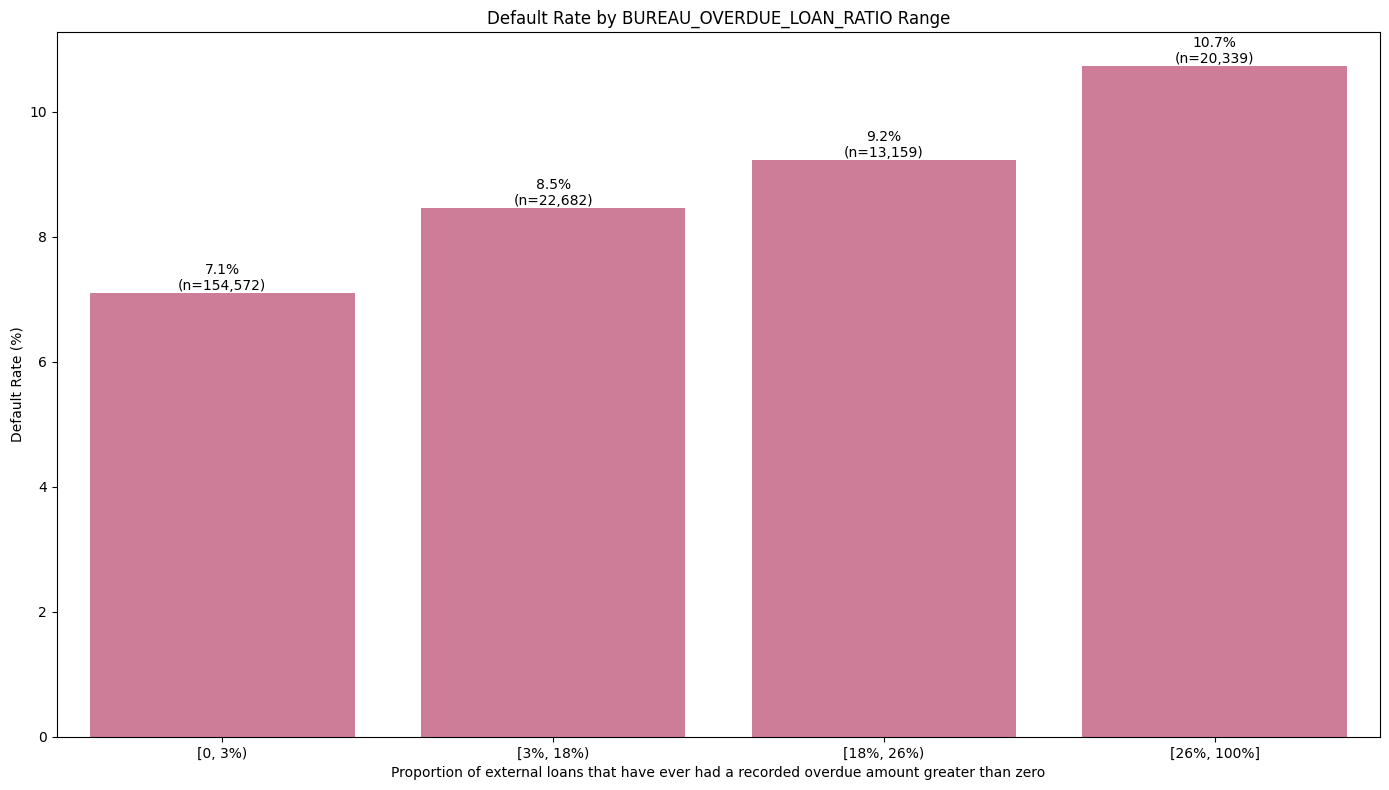

In [39]:
bins = [0, 0.032, 0.175, 0.264, 100]

labels = [
    "[0, 3%)",
    "[3%, 18%)",
    "[18%, 26%)",
    "[26%, 100%]"
]

df_plot = feature_store[["TARGET", feature_name]].copy()

df_plot["LOAN_COUNT_BIN"] = pd.cut(
    df_plot[feature_name],
    bins=bins,
    labels=labels,
    right=False
)

default_rate = (
    df_plot
    .groupby("LOAN_COUNT_BIN", observed=False)
    .agg(
        default_rate=("TARGET", "mean"),
        total_clients=("TARGET", "count"),
        total_defaults=("TARGET", "sum")
    )
    .reset_index()
)

default_rate["default_rate"] *= 100

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=default_rate,
    x="LOAN_COUNT_BIN",
    y="default_rate",
    color="palevioletred"
)

plt.title(f"Default Rate by {feature_name} Range")
plt.xlabel("Proportion of external loans that have ever had a recorded overdue amount greater than zero")
plt.ylabel("Default Rate (%)")

for p, row in zip(ax.patches, default_rate.itertuples()):
    height = p.get_height()

    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.1f}%\n(n={row.total_clients:,})",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

**BUREAU_OVERDUE_LOAN_RATIO** shows a clear monotonic relationship with default risk. The default rate increases from **7.1%** among clients with less than 3% of external loans presenting overdue records to **10.7%** among those with ratios above 26%. The intermediate groups follow the same increasing pattern, with default rates of **8.5%** and **9.2%**, respectively. This suggests that a higher proportion of external loans with previous overdue records is associated with increased credit risk, capturing the client's historical payment behavior across external credit relationships.

# 4. Relationship With the Institution

- PREV_REFUSED_RATIO
- PREV_CREDIT_TO_APPLICATION_RATIO_MEAN

---
**Feature 4.1: PREV_REFUSED_RATIO**

Formula:
REFUSED_RATIO = PREV_REFUSED_COUNT / PREV_APP_COUNT

Interpretation:
Proportion of rejected applications.

In [40]:
feature_name = "PREV_REFUSED_RATIO"
missing_rate = feature_store[feature_name].isna().mean() * 100

print(f"{feature_name} missing rate: {missing_rate:.2f}%")

PREV_REFUSED_RATIO missing rate: 5.36%


In [41]:
x = feature_store[feature_name]
y = feature_store["TARGET"]

optb = OptimalBinning(
    name=feature_name,
    dtype="numerical",
    solver="cp"
)

optb.fit(x, y)

binning_table = optb.binning_table.build()
binning_table

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.06)",152674,0.620606,141902,10772,0.070556,0.145705,0.012396,0.001548
1,"[0.06, 0.16)",13325,0.054165,12349,976,0.073246,0.105386,0.000576,0.000072
2,"[0.16, 0.21)",13213,0.053710,12125,1088,0.082343,-0.021554,0.000025,0.000003
3,"[0.21, 0.28)",12415,0.050466,11284,1131,0.091099,-0.132198,0.000932,0.000116
4,"[0.28, 0.44)",21702,0.088217,19363,2339,0.107778,-0.318841,0.010252,0.001276
5,"[0.44, inf)",19505,0.079286,16742,2763,0.141656,-0.630879,0.041066,0.005050
6,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
7,Missing,13174,0.053551,12383,791,0.060043,0.3183,0.004751,0.000591
Totals,,246008,1.000000,226148,19860,0.080729,,0.069998,0.008657


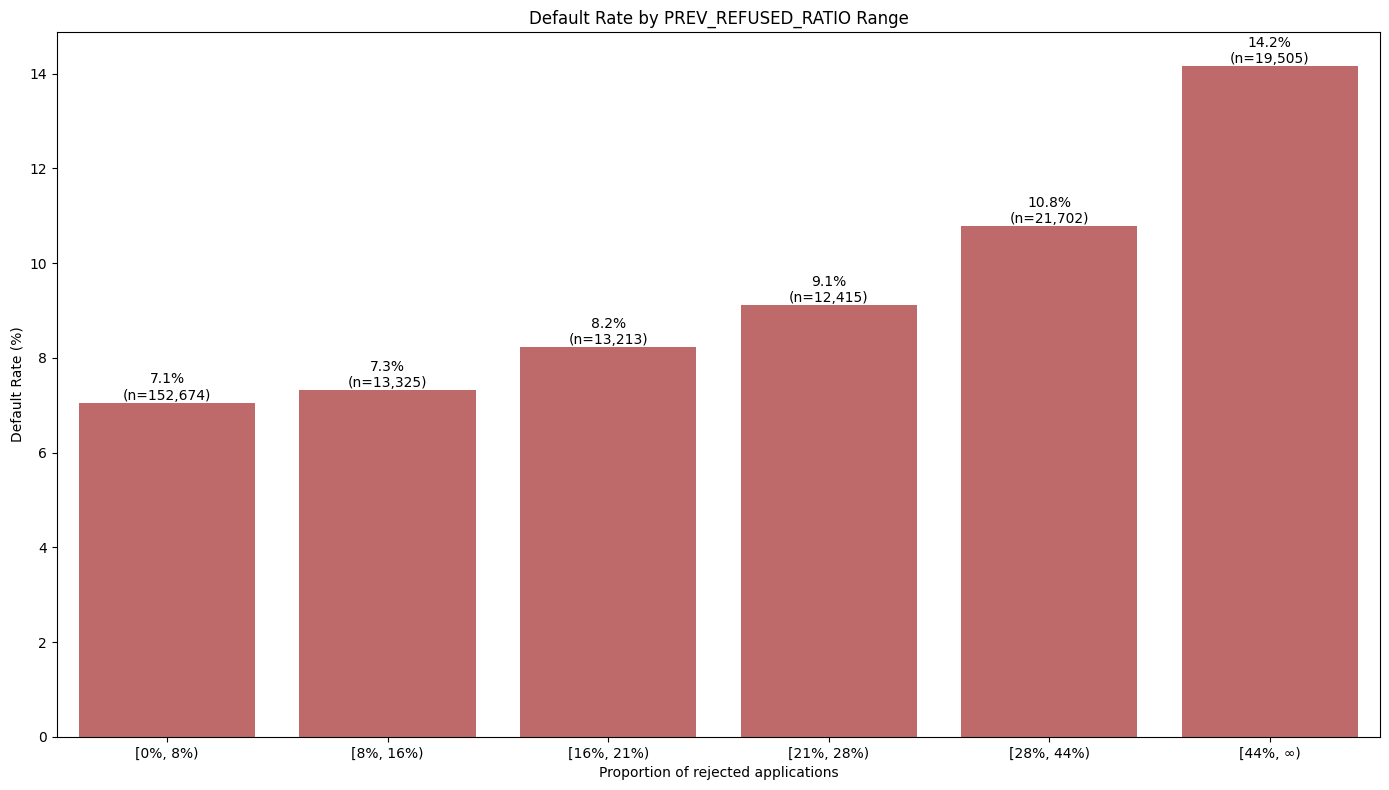

In [42]:
# Optimal bins for PREV_REFUSED_RATIO
bins = np.concatenate([
    [0],
    optb.splits,
    [np.inf]
])

labels = [
    "[0%, 8%)",
    "[8%, 16%)",
    "[16%, 21%)",
    "[21%, 28%)",
    "[28%, 44%)",
    "[44%, ∞)"
]

df_plot = feature_store[
    ["TARGET", feature_name]
].copy()

df_plot["PREV_REFUSED_RATIO_BIN"] = pd.cut(
    df_plot[feature_name],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

default_rate = (
    df_plot
    .groupby("PREV_REFUSED_RATIO_BIN", observed=False)
    .agg(
        default_rate=("TARGET", "mean"),
        total_clients=("TARGET", "count"),
        total_defaults=("TARGET", "sum")
    )
    .reset_index()
)

default_rate["default_rate"] *= 100

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=default_rate,
    x="PREV_REFUSED_RATIO_BIN",
    y="default_rate",
    color="indianred"
)

plt.title(f"Default Rate by {feature_name} Range")

plt.xlabel(
    "Proportion of rejected applications"
)

plt.ylabel("Default Rate (%)")

for p, row in zip(ax.patches, default_rate.itertuples()):
    height = p.get_height()

    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.1f}%\n(n={row.total_clients:,})",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [43]:
df_plot[feature_name].quantile(
    [0, .25, .50,.75,.90,.95,.99,.995,.999]
)

0.000    0.000000
0.250    0.000000
0.500    0.000000
0.750    0.200000
0.900    0.400000
0.950    0.500000
0.990    0.717277
0.995    0.800000
0.999    1.000000
Name: PREV_REFUSED_RATIO, dtype: float32

In [44]:
print(f"{round((df_plot[feature_name] == 0).mean()*100,2)}% of customers have never experienced a rejected application")

61.99% of customers have never experienced a rejected application


---
`PREV_REFUSED_RATIO` shows a clear positive relationship with default risk. The default rate increases from **7.1%** for clients with a low proportion of rejected applications to **14.2%** when rejected applications represent 44% or more of the client's previous applications.

The feature is strongly concentrated at zero, with **62.0% of clients having no previous rejected applications**. Among clients with rejection history, higher rejection ratios are consistently associated with higher default rates, suggesting that repeated credit application refusals capture relevant information about the client's previous credit risk profile.

The bin thresholds were identified using **Optimal Binning** rather than defined arbitrarily.

---
**Feature 4.2: PREV_CREDIT_TO_APPLICATION_RATIO_MEAN**

**Formula:**

CREDIT_TO_APPLICATION_RATIO = AMT_CREDIT / AMT_APPLICATION

(Mean across previous applications.)

**Definition:**

Average ratio between the final credit amount determined during the approval
process and the credit amount initially requested by the client.

**Interpretation:**

Measures how the final credit amount compares with the amount initially requested.

- Values < 1 → final credit amount was lower than initially requested
- Values ≈ 1 → final credit amount was close to the initially requested amount
- Values > 1 → final credit amount was higher than initially requested

**Signal captured:**

- Historical credit approval adjustments
- Differences between requested and final credit amounts

In [45]:
feature_name = "PREV_CREDIT_TO_APPLICATION_RATIO_MEAN"
missing_rate = feature_store[feature_name].isna().mean() * 100

print(f"{feature_name} missing rate: {missing_rate:.2f}%")

PREV_CREDIT_TO_APPLICATION_RATIO_MEAN missing rate: 5.36%


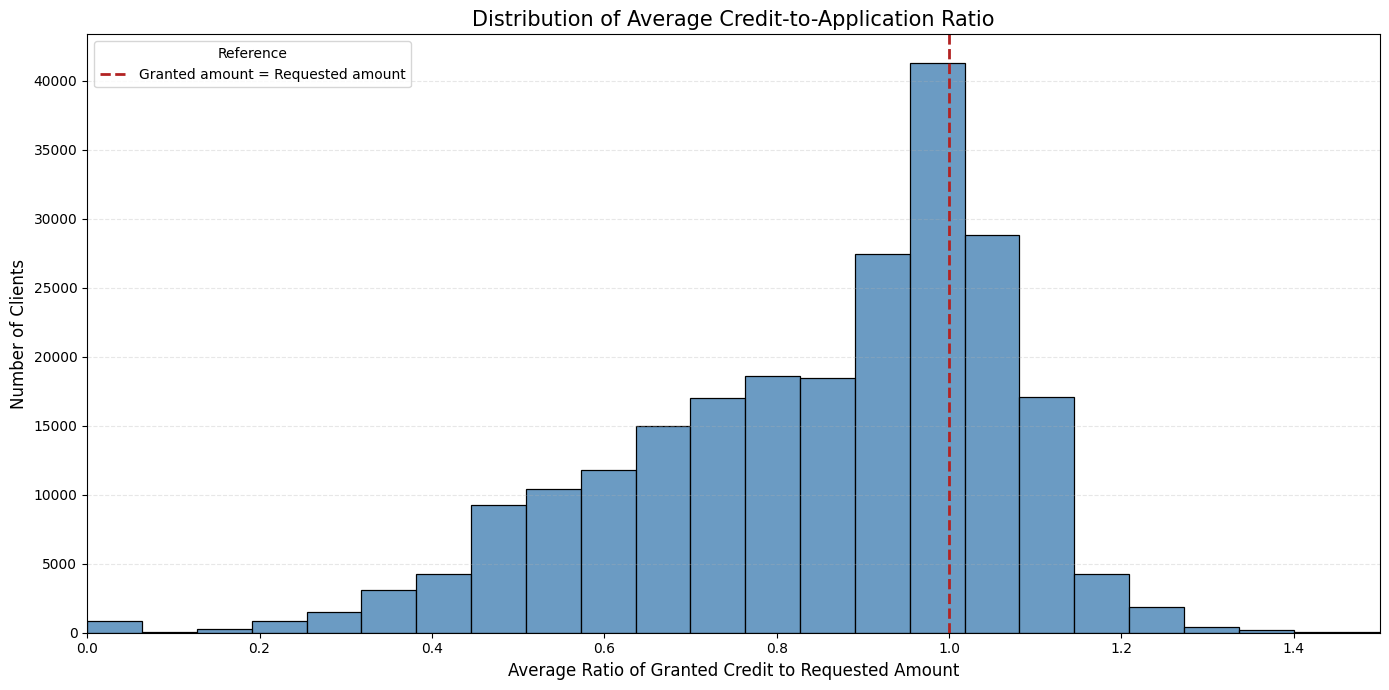

In [46]:
feature_name = "PREV_CREDIT_TO_APPLICATION_RATIO_MEAN"

plt.figure(figsize=(14, 7))

ax = sns.histplot(
    data=feature_store,
    x=feature_name,
    bins=80,
    color="steelblue",
    alpha=0.8
)

# Reference line: granted credit = requested amount
ax.axvline(
    x=1,
    color="firebrick",
    linestyle="--",
    linewidth=2,
    label="Granted amount = Requested amount"
)

# Focus on the region containing almost all observations
ax.set_xlim(0, 1.5)

# Titles and labels
ax.set_title(
    "Distribution of Average Credit-to-Application Ratio",
    fontsize=15
)

ax.set_xlabel(
    "Average Ratio of Granted Credit to Requested Amount",
    fontsize=12
)

ax.set_ylabel(
    "Number of Clients",
    fontsize=12
)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Legend
ax.legend(
    title="Reference",
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [47]:
x = feature_store[
    feature_name
].dropna()

is_equal_1 = np.isclose(x, 1, atol=1e-4)

print(f"Ratio < 1:  {((x < 1) & ~is_equal_1).mean() * 100:.2f}%")
print(f"Ratio ≈ 1:  {is_equal_1.mean() * 100:.2f}%")
print(f"Ratio > 1:  {((x > 1) & ~is_equal_1).mean() * 100:.2f}%")

Ratio < 1:  69.22%
Ratio ≈ 1:  4.95%
Ratio > 1:  25.83%


In [48]:
df_analysis = feature_store[
    [feature_name, "TARGET"]
].dropna().copy()

x = df_analysis[feature_name]

is_equal_1 = np.isclose(x, 1, atol=1e-4)

df_analysis["RATIO_GROUP"] = np.select(
    [
        (x < 1) & ~is_equal_1,
        is_equal_1,
        (x > 1) & ~is_equal_1
    ],
    [
        "Ratio < 1",
        "Ratio ≈ 1",
        "Ratio > 1"
    ],
    default="Other"
)

ratio_summary = (
    df_analysis
    .groupby("RATIO_GROUP")
    .agg(
        clients=("TARGET", "count"),
        defaults=("TARGET", "sum"),
        default_rate=("TARGET", "mean")
    )
)

ratio_summary["default_rate"] *= 100

ratio_summary

,clients,defaults,default_rate
RATIO_GROUP,,,
Ratio < 1,161164,12782,7.931052
Ratio > 1,60148,5436,9.037707
Ratio ≈ 1,11522,851,7.385871


In [49]:
df_prev = (
    feature_store[
        [feature_name, "TARGET"]
    ]
    .dropna()
    .copy()
)

optb = OptimalBinning(
    name=feature_name,
    dtype="numerical",
    solver="cp"
)

optb.fit(
    df_prev[
        feature_name
    ],
    df_prev["TARGET"]
)

binning_table = optb.binning_table.build()

binning_table

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.61)",36611,0.157241,33362,3249,0.088744,-0.087743,0.001256,0.000157
1,"[0.61, 0.77)",39560,0.169906,36342,3218,0.081345,0.007401,0.000009,0.000001
2,"[0.77, 0.90)",37354,0.160432,34453,2901,0.077662,0.057727,0.000522,0.000065
3,"[0.90, 0.94)",20037,0.086057,18627,1410,0.070370,0.164209,0.002167,0.000271
4,"[0.94, 0.97)",11652,0.050044,10861,791,0.067885,0.202822,0.001892,0.000236
5,"[0.97, 1.03)",39597,0.170065,36695,2902,0.073288,0.120427,0.002345,0.000293
6,"[1.03, 1.08)",23136,0.099367,21213,1923,0.083117,-0.016086,0.000026,0.000003
7,"[1.08, 1.12)",13244,0.056882,11961,1283,0.096874,-0.184363,0.002088,0.000261
8,"[1.12, inf)",11643,0.050006,10251,1392,0.119557,-0.42018,0.010523,0.001306
9,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000


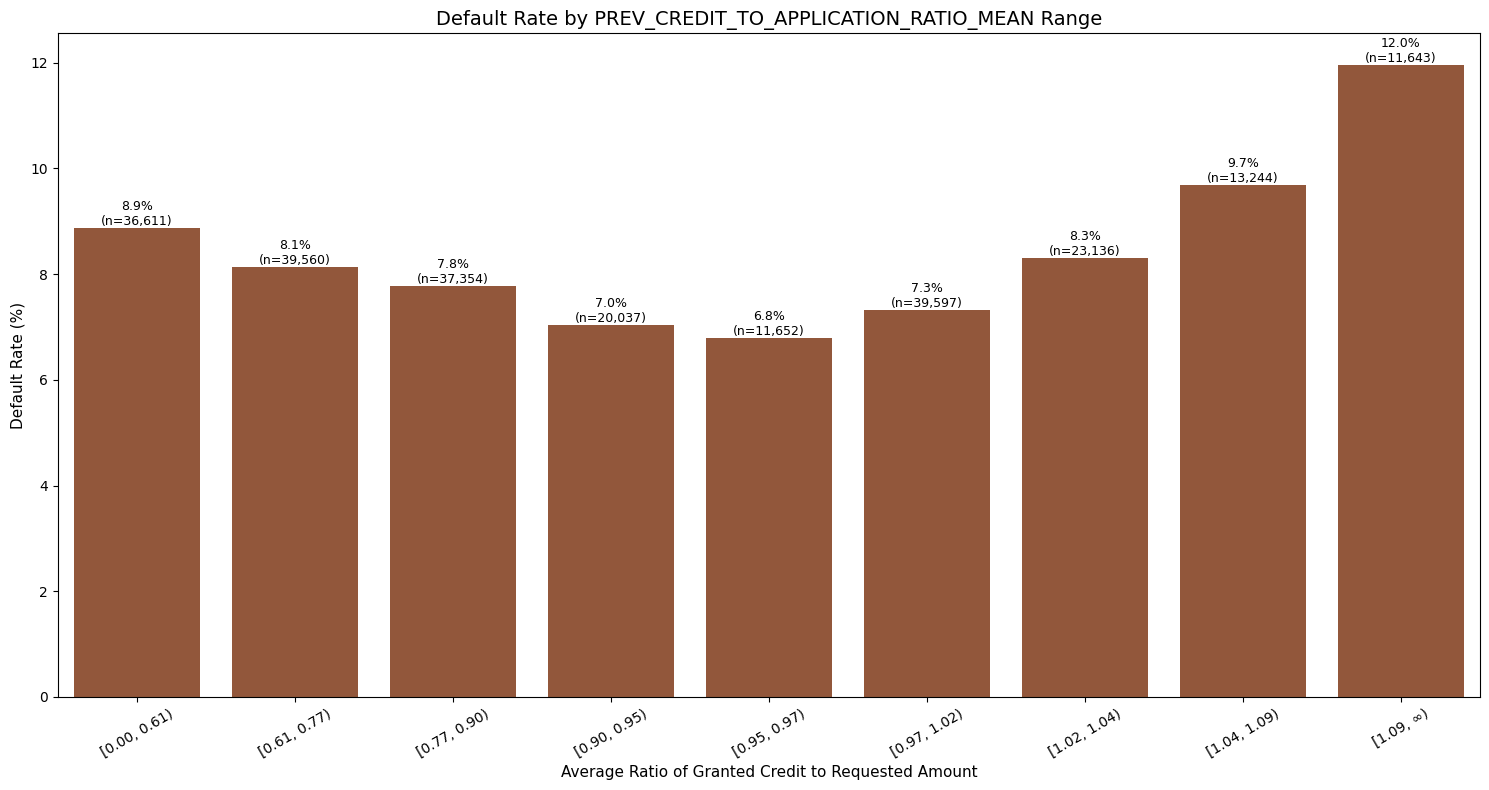

In [50]:
# Optimal bins
bins = np.concatenate([
    [0],
    optb.splits,
    [np.inf]
])

labels = [
    "[0.00, 0.61)",
    "[0.61, 0.77)",
    "[0.77, 0.90)",
    "[0.90, 0.95)",
    "[0.95, 0.97)",
    "[0.97, 1.02)",
    "[1.02, 1.04)",
    "[1.04, 1.09)",
    "[1.09, ∞)"
]

# Keep only necessary columns and remove missing values
df_plot = (
    feature_store[[feature_name, "TARGET"]]
    .dropna(subset=[feature_name])
    .copy()
)

# Create bins
df_plot["CREDIT_APPLICATION_RATIO_BIN"] = pd.cut(
    df_plot[feature_name],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

# Calculate default rate
default_rate = (
    df_plot
    .groupby("CREDIT_APPLICATION_RATIO_BIN", observed=False)
    .agg(
        default_rate=("TARGET", "mean"),
        total_clients=("TARGET", "count"),
        total_defaults=("TARGET", "sum")
    )
    .reset_index()
)

default_rate["default_rate"] *= 100

# Plot
plt.figure(figsize=(15, 8))

ax = sns.barplot(
    data=default_rate,
    x="CREDIT_APPLICATION_RATIO_BIN",
    y="default_rate",
    color="sienna"
)

plt.title(
    "Default Rate by PREV_CREDIT_TO_APPLICATION_RATIO_MEAN Range",
    fontsize=14
)

plt.xlabel(
    "Average Ratio of Granted Credit to Requested Amount",
    fontsize=11
)

plt.ylabel(
    "Default Rate (%)",
    fontsize=11
)

# Labels
for p, row in zip(ax.patches, default_rate.itertuples()):
    height = p.get_height()

    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.1f}%\n(n={row.total_clients:,})",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

---

`PREV_CREDIT_TO_APPLICATION_RATIO_MEAN` shows a **non-linear relationship with default risk**. Default rates decrease as the final credit amount approaches the initially requested amount, reaching the lowest level (**6.8%**) around a ratio of 0.95–0.97, and increase again when the final credit amount exceeds the requested amount, reaching **12%** for ratios above 1.09.

This suggests that **larger deviations between requested and final credit amounts are associated with higher observed default risk**, although the underlying approval mechanisms should not be interpreted causally. The bin thresholds were identified using **Optimal Binning** rather than defined arbitrarily.